**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

*   NOMBRES: Karla Julieta Gómez Martínez, Jorge Emilio Gómez Delgadillo, Luis Aaron Gómez Castillo, Fernando Gomez Moreno
*   MATRÍCULAS: A01642064, A01797722, A01797925, A00354097

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [2]:
cancer_df = pd.read_csv("/Users/chicano/Documents/Tec/1-Trimestre/Ciencia y Analisis de datos/Semana 9 (Nov 3 Nov 9)/Actividad 9 - Regresion Logistica/breast_cancer.csv")

# Set 'id' as the new index
cancer_df.set_index('id', inplace=True)

cancer_df.info()
# Columnas = 32 total
# 31 Numéricas
# 1 Texto

# Calculate the total count of missing values for each column
missing_values = cancer_df.isnull().sum()
missing_values_count = missing_values[missing_values > 0]

print("Columnas con valores faltantes:")
if missing_values_count.empty:
    print("No hay valores faltantes en ninguna columna.")
else:
    print(missing_values_count.to_markdown(numalign="left", stralign="left"))

# Verificar duplicados (se consideran duplicadas si todos los valores de las columnas son idénticos)
num_duplicates = cancer_df.duplicated().sum()
print("\n--- Duplicate Check ---")
print(f"Number of duplicate rows found: {num_duplicates}")

cancer_df = cancer_df.drop_duplicates()
cancer_df.reset_index(drop=True, inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

In [3]:
# Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.
# Separar columnas
# 'diagnosis' es la única columna categórica.
categorical_cols = ['diagnosis']
numerical_df = cancer_df.drop(columns=categorical_cols)
categorical_df = cancer_df[categorical_cols]

# Calcular estadísticas para datos numéricos
numerical_stats = numerical_df.describe().T # .T para transponer y hacer más legible
numerical_stats['skewness'] = numerical_df.skew() # Asimetría
numerical_stats['kurtosis'] = numerical_df.kurt() # Curtosis
numerical_stats = numerical_stats.round(3)

# Calcular estadísticas para datos categóricos
categorical_stats = categorical_df.describe()

# Formatear y presentar los resultados
print("---------- Estadisticas descriptivas para variables númericas ----------")
print(numerical_stats.to_markdown(numalign="left", stralign="left"))

print("\n---------- Estadisticas descriptivas para variables categoricas ('diagnosis') ----------")
print(categorical_stats.to_markdown(numalign="left", stralign="left"))

---------- Estadisticas descriptivas para variables númericas ----------
|                         | count   | mean    | std     | min   | 25%   | 50%   | 75%   | max   | skewness   | kurtosis   |
|:------------------------|:--------|:--------|:--------|:------|:------|:------|:------|:------|:-----------|:-----------|
| radius_mean             | 569     | 14.127  | 3.524   | 6.981 | 11.7  | 13.37 | 15.78 | 28.11 | 0.942      | 0.846      |
| texture_mean            | 569     | 19.29   | 4.301   | 9.71  | 16.17 | 18.84 | 21.8  | 39.28 | 0.65       | 0.758      |
| perimeter_mean          | 569     | 91.969  | 24.299  | 43.79 | 75.17 | 86.24 | 104.1 | 188.5 | 0.991      | 0.972      |
| area_mean               | 569     | 654.889 | 351.914 | 143.5 | 420.3 | 551.1 | 782.7 | 2501  | 1.646      | 3.652      |
| smoothness_mean         | 569     | 0.096   | 0.014   | 0.053 | 0.086 | 0.096 | 0.105 | 0.163 | 0.456      | 0.856      |
| compactness_mean        | 569     | 0.104   | 0.053   | 0

2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

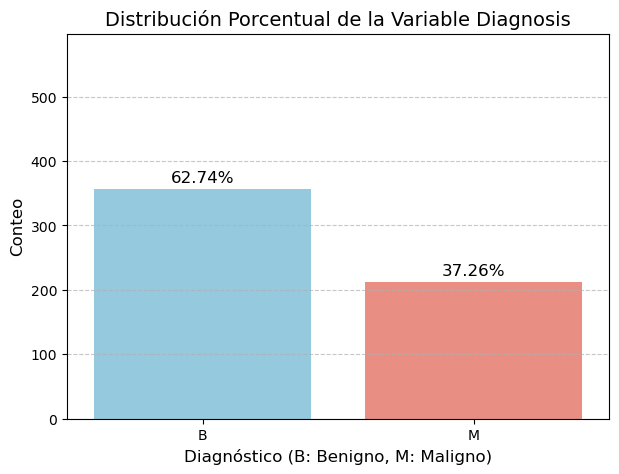

In [4]:
# Calcular el conteo and porcentajes de la columna 'diagnosis'
diagnosis_counts = cancer_df['diagnosis'].value_counts()
total_count = diagnosis_counts.sum()
diagnosis_percentages = (diagnosis_counts / total_count) * 100

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Diagnosis': diagnosis_counts.index,
    'Count': diagnosis_counts.values,
    'Percentage': diagnosis_percentages.values
})

plt.figure(figsize=(7, 5))
sns.barplot(x='Diagnosis', y='Count', data=plot_df, hue='Diagnosis', palette=['skyblue', 'salmon'], legend=False)

# 5. Add percentage labels on top of each bar
for index, row in plot_df.iterrows():
    plt.text(
        index, # x-coordinate (0 for 'B', 1 for 'M')
        row['Count'] + 5, # y-coordinate (just above the bar)
        f"{row['Percentage']:.2f}%", # Text to display
        color='black',
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.title('Distribución Porcentual de la Variable Diagnosis', fontsize=14)
plt.xlabel('Diagnóstico (B: Benigno, M: Maligno)', fontsize=12)
plt.ylabel('Conteo', fontsize=12)
plt.ylim(0, total_count * 1.05) # Adjust y-limit to fit the labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
plt.close()

# ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
La distribución de la variable de salida, como diagnosis, es crucial en cualquier problema de clasificación por las siguientes razones:
- Determinar si el conjunto de datos está balanceado o desbalanceado, como en este caso existe un balance moderado ya que la clase Benigna (B) es más comun (62.74%)
- Porque afecta las métricas (accuracy puede verse afectada si hay desbalance).

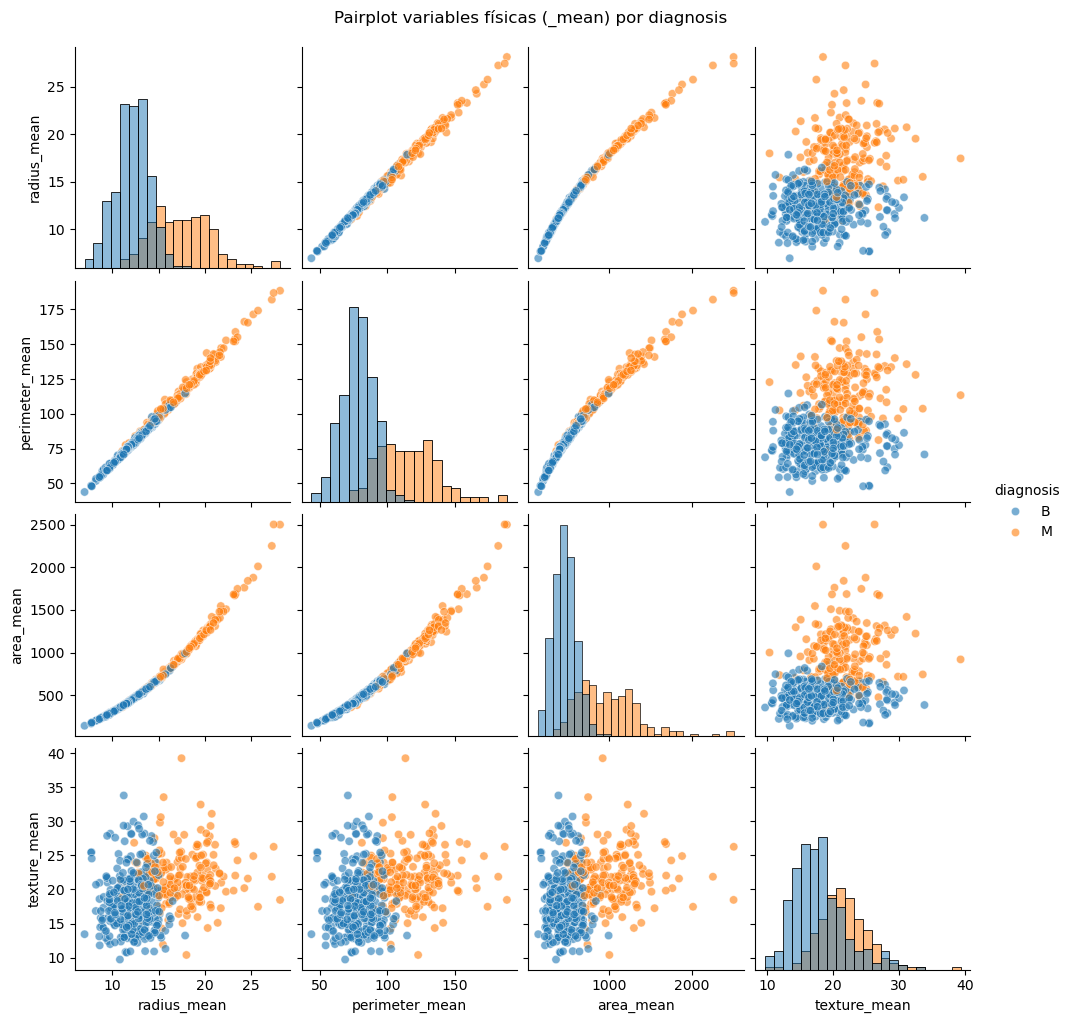

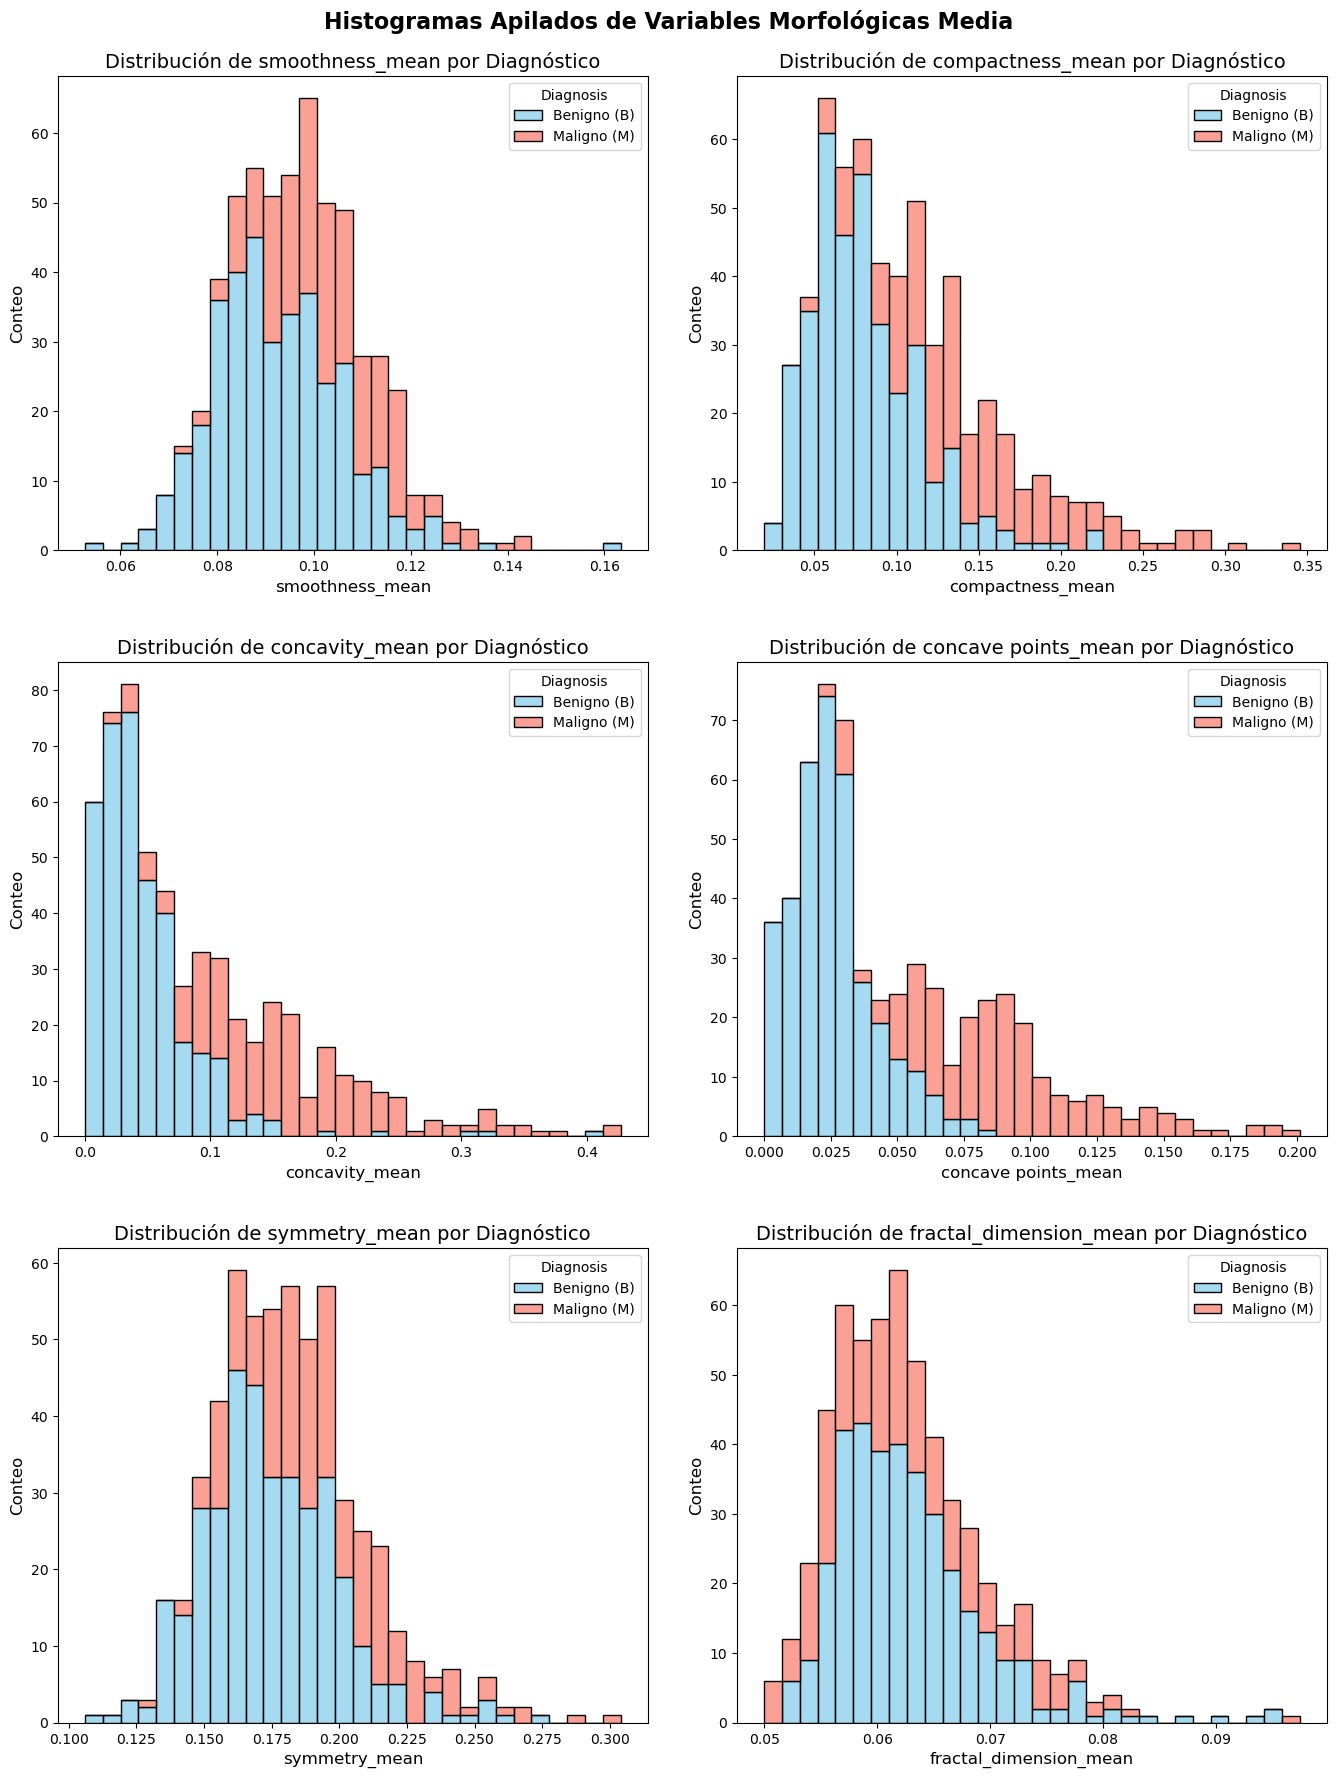

In [5]:
# Genera un pairplot de las variables físicas del conjunto _mean (radius_mean, perimeter_mean, area_mean, texture_mean) 
# coloreando por la variable diagnosis. ¿Qué relaciones observas entre las variables físicas? 
# ¿Qué diferencias hay entre los tumores benignos y malignos?

# Genera un pairplot de las variables físicas del conjunto _mean (radius_mean, perimeter_mean, area_mean, texture_mean) coloreando por la variable diagnosis.
# ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
phys_vars = ["radius_mean", "perimeter_mean", "area_mean", "texture_mean"]
 
sns.pairplot(cancer_df[phys_vars + ["diagnosis"]],
             hue="diagnosis",
             hue_order=["B", "M"],
             diag_kind="hist",
             plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot variables físicas (_mean) por diagnosis", y=1.02)
plt.show()

# ¿Qué relaciones observas entre las variables físicas? 
# Hay una correlación positiva muy fuerte entre radius_mean, perimeter_mean y area_mean es esperado ya que estas variables
# miden el tamaño del tumor y son interdependientes. Un radio más grande implica un perimétro y area más grandes.
# La variable texture_mean muestra una correlación positiva pero más debil con las variables de tamaño (radius_mean, perimeter_mean, area_mean).
# Los tumores más grandes tienden a tener texturas medias más altas.

# ¿Qué diferencias hay entre los tumores benignos y malignos?
# Las diferencias entre los tumores Benigno y Maligno estan en las variables relacionadas con el tamaño.
# Los tumores malignos (M) se agrupan consistentemente en los valores más altos para estas tres variables.
# Los tumores benignos (B) se agrupan el los valores más bajos.

# Las variables que miden el tamaño del tumor (radius_mean, perimeter_mean, area_mean) 
# son los predictores más importantes y están fuertemente correlacionadas con la malignidad. 
# Los tumores malignos tienden a ser significativamente más grandes que los benignos.


# Definir la lista de variables morfológicas
morphological_features = [
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean'
]

# Setup the figure layout (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
palette = {'B': 'skyblue', 'M': 'salmon'}

for i, feature in enumerate(morphological_features):
    sns.histplot(
        data=cancer_df,
        x=feature,
        hue='diagnosis',
        multiple='stack', # Key argument for stacked histograms
        palette=palette,
        ax=axes[i],
        bins=30, # Use 30 bins for better resolution
        edgecolor='black'
    )
    axes[i].set_title(f'Distribución de {feature} por Diagnóstico', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Conteo', fontsize=12)
    axes[i].legend(title='Diagnosis', labels=['Benigno (B)', 'Maligno (M)'])

plt.tight_layout(pad=3.0)
plt.suptitle('Histogramas Apilados de Variables Morfológicas Media', y=1.00, fontsize=16, weight='bold')


plt.show()
plt.close()

# Las variables concave_points_mean y concavity_mean son los mejores discriminadores entre los tumores Benignos (B) y Malignos (M).
# La presencia de puntos cóncavos y una alta concavidad en el contorno del núcleo 
# son características morfológicas clave para identificar la malignidad. 
# Los tumores malignos tienden a presentar geometrías más complejas y menos uniformes.


3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [6]:
cancer_copy = cancer_df.copy(deep=True)
print("--- Información del nuevo DataFrame 'cancer_copy' ---")
print(cancer_copy.info())

# Calcular la matriz de correlacion absoluta
corr_matrix = numerical_df.corr().abs()

# Identificar pares altamentente correlacionales (> 0.9)
# Usa un bandera booleana para seleccionar pares y unstack la matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Stack the upper triangle to get a Series, then filter by threshold
highly_correlated_pairs = upper.unstack().sort_values(ascending=False)
highly_correlated_pairs = highly_correlated_pairs[highly_correlated_pairs > 0.90]

print("--- Pares de Variables con Correlación Absoluta > 0.90 ---")
print(highly_correlated_pairs.to_markdown(numalign="left", stralign="left", headers=['Variables', 'Valor', 'Correlación']))

# Eliminar las columnas que terminan con '_worst'
columns_to_drop = [col for col in cancer_copy.columns if col.endswith('_worst')]

print(f"\nColumnas a eliminar (terminan en '_worst'): {', '.join(columns_to_drop)}")

# Drop las columnas identificadas del DataFrame
cancer_copy.drop(columns=columns_to_drop, inplace=True)

# 5. Verificar el DataFrame resultante
print("\n--- Estado Final del DataFrame ---")
print(f"Nueva forma (filas, columnas): {cancer_copy.shape}")
print(f"Columnas restantes: {', '.join(cancer_copy.columns)}")


--- Información del nuevo DataFrame 'cancer_copy' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             5

In [7]:
# Recalcular e imprimir pares altamente correlacionados (> 0.9)
numerical_df = cancer_copy.drop(columns=['diagnosis'])
corr_matrix = numerical_df.corr().abs()

# Identificar y mostrar pares con correlación > 0.9
# Usamos una máscara para la parte superior de la matriz y así evitar duplicados
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated_pairs = []
for column in upper.columns:
    correlated_features = upper[column][upper[column] > 0.9].index.tolist()
    for feature in correlated_features:
        highly_correlated_pairs.append((feature, column, upper.loc[feature, column]))

print("--- Pares de Variables con Correlación Absoluta > 0.9 (Data después de eliminar '_worst') ---")
if highly_correlated_pairs:
    highly_correlated_pairs.sort(key=lambda x: x[2], reverse=True)
    for feature1, feature2, corr_value in highly_correlated_pairs:
        print(f"({feature1}, {feature2}): {corr_value:.4f}")
else:
    print("No se encontraron pares de variables con correlación absoluta > 0.9.")

print("\n--- Decisión sobre 'radius', 'perimeter' y 'area' ---")
print("De las tres medidas de tamaño altamente correlacionadas: 'radius_mean', 'perimeter_mean' y 'area_mean', se mantendrá 'radius_mean'.")
print("Justificación: El radio ('radius_mean') es la medida geométrica más fundamental del tamaño del tumor.")
print("Eliminaremos: 'perimeter_mean' y 'area_mean'.")

# Adicionalmente, se recomienda encarecidamente eliminar las contrapartes '_se' por la misma razón:
# (radius_se, perimeter_se) -> 0.9728, (radius_se, area_se) -> 0.9518.
# Para simplificar y mantener solo la medida fundamental (radius_se) para la variación:

# Eliminar columnas redundantes de tamaño ('perimeter', 'area')
columns_to_drop_size = ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se']
cancer_copy.drop(columns=columns_to_drop_size, inplace=True)

# --- Correlation and Visualization ---

# Aísla las características numéricas finales
numerical_df = cancer_copy.drop(columns=['diagnosis'])

# 4. Calcular la matriz de correlación
corr_matrix = numerical_df.corr()


# Imprimir el resultado final
print("\n--- Resultado Final del DataFrame ---")
print(f"Columnas eliminadas: {columns_to_drop_size}")
print(f"Nueva forma final de df: {cancer_copy.shape}")
print(f"Total de características restantes: {cancer_copy.shape[1] - 1}")
print("\nColumnas restantes:")
print(cancer_copy.columns.tolist())

--- Pares de Variables con Correlación Absoluta > 0.9 (Data después de eliminar '_worst') ---
(radius_mean, perimeter_mean): 0.9979
(radius_mean, area_mean): 0.9874
(perimeter_mean, area_mean): 0.9865
(radius_se, perimeter_se): 0.9728
(radius_se, area_se): 0.9518
(perimeter_se, area_se): 0.9377
(concavity_mean, concave points_mean): 0.9214

--- Decisión sobre 'radius', 'perimeter' y 'area' ---
De las tres medidas de tamaño altamente correlacionadas: 'radius_mean', 'perimeter_mean' y 'area_mean', se mantendrá 'radius_mean'.
Justificación: El radio ('radius_mean') es la medida geométrica más fundamental del tamaño del tumor.
Eliminaremos: 'perimeter_mean' y 'area_mean'.

--- Resultado Final del DataFrame ---
Columnas eliminadas: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se']
Nueva forma final de df: (569, 17)
Total de características restantes: 16

Columnas restantes:
['diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concav

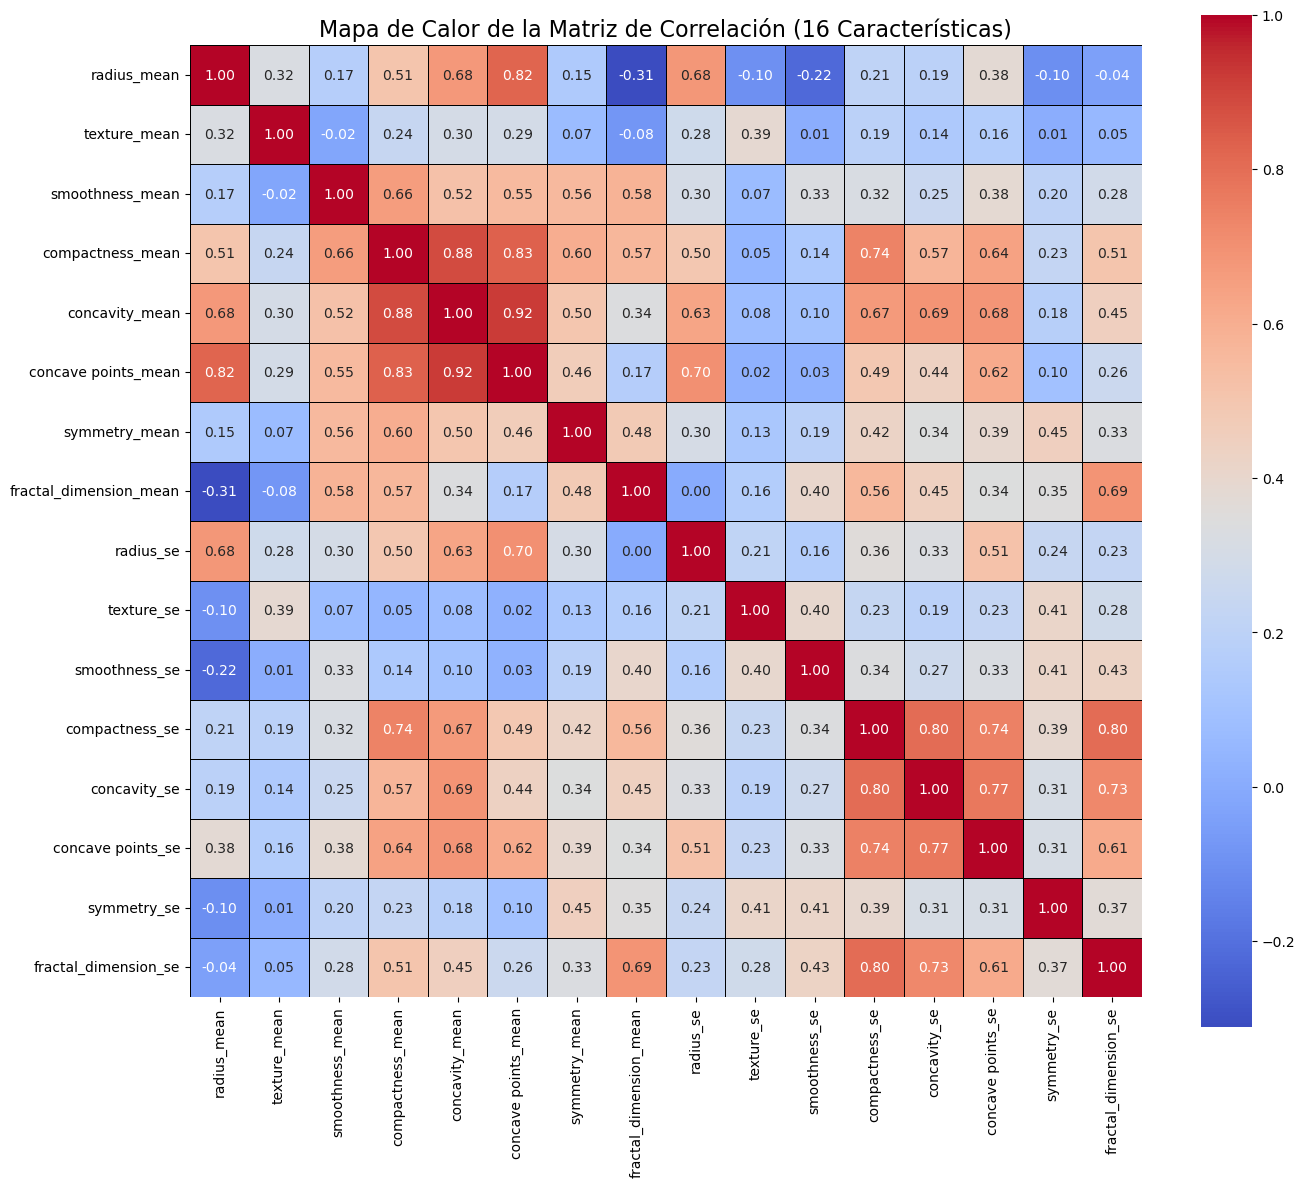

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   smoothness_mean         569 non-null    float64
 4   compactness_mean        569 non-null    float64
 5   concave points_mean     569 non-null    float64
 6   symmetry_mean           569 non-null    float64
 7   fractal_dimension_mean  569 non-null    float64
 8   radius_se               569 non-null    float64
 9   texture_se              569 non-null    float64
 10  smoothness_se           569 non-null    float64
 11  compactness_se          569 non-null    float64
 12  concavity_se            569 non-null    float64
 13  concave points_se       569 non-null    float64
 14  symmetry_se             569 non-null    fl

In [8]:
# Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. 
# Si eliminas alguna otra variable, justifica tu elección.

# Generamos el mapa de calor
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
    square=True
)
plt.title('Mapa de Calor de la Matriz de Correlación (16 Características)', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

# concavity_mean y concave points_mean tienen una correlación de 0.92
# Por lo que solo vamos a conservar 'concave points_mean' (discriminó muy bien en tus histogramas) y eliminar 'concavity_mean'.
opt_drop = []
if "concavity_mean" in cancer_copy.columns:
    opt_drop.append("concavity_mean")
if opt_drop:
    cancer_copy = cancer_copy.drop(columns=opt_drop)

cancer_copy.info()

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [9]:
# Codificar la variable de salida (M=1, B=0)
# Esto es necesario para que 'y' sea un vector numérico.
cancer_df['diagnosis_encoded'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})

# Separar las variables predictoras (X) de la variable de salida (y)
# X contendrá TODAS las 30 características originales (excluyendo 'id' y las columnas de 'diagnosis')
X = cancer_df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = cancer_df['diagnosis_encoded']

print("----- Codificación y Separación X/y -----")
print(f"X (Predictoras) forma: {X.shape}")
print(f"y (Salida) forma: {y.shape}")
print(f"Codificación: M = 1, B = 0")

# ----- División Train/Test (80:20) -----

random_state_value = 1
test_size_value = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size_value,
    random_state=random_state_value,
    stratify=y  # Mantiene la proporción de M/B en ambos sets
)

print("\n----- División Train/Test (random_state=1) -----")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Distribución de y_train:\n{y_train.value_counts(normalize=True).round(4).to_markdown(numalign='left', stralign='left')}")

# ----- Definir la función evaluate_model -----
# Esta función se define en el entorno para su uso futuro, pero su definición se imprime aquí.

def evaluate_model(y_true, y_pred):
    """
    Calcula e imprime el recall, la precisión y la exactitud (accuracy).
    """
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    return {
        'Recall': recall,
        'Precision': precision,
        'Accuracy': accuracy
    }

----- Codificación y Separación X/y -----
X (Predictoras) forma: (569, 30)
y (Salida) forma: (569,)
Codificación: M = 1, B = 0

----- División Train/Test (random_state=1) -----
X_train shape: (455, 30)
X_test shape:  (114, 30)
Distribución de y_train:
| diagnosis_encoded   | proportion   |
|:--------------------|:-------------|
| 0                   | 0.6264       |
| 1                   | 0.3736       |


5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [10]:
# Columnas a eliminar (total 15 columnas)
columns_to_drop = [
    # 10 Columnas '_worst'
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst',
    # 5 Columnas redundantes de 'mean'/'se'
    'perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'concavity_mean'
]

# El transformador 'preprocessing' para ELIMINAR las columnas
# La lista de columnas a transformar es irrelevante para 'drop', pero debe ser una lista.
# Se usa 'all' para asegurar que ColumnTransformer considere todas las columnas de X
# pero la transformación 'drop' solo se aplica a las definidas en 'columns_to_drop'.
preprocessing = ColumnTransformer(
    transformers=[
        ('drop_cols', 'drop', columns_to_drop) # Aplica la acción 'drop' a las columnas seleccionadas
    ],
    remainder='passthrough', # Mantiene las 15 columnas restantes (las que vamos a usar)
    verbose_feature_names_out=False
)

print("----- Transformador 'preprocessing' Definido -----")
print(f"Columnas a ELIMINAR ({len(columns_to_drop)}): {columns_to_drop}")

# ----- Crear un pipeline que integre el transformador y Regresión Logística -----

# Las 15 columnas que pasan necesitan ser escaladas antes de la Regresión Logística.
# Usamos un segundo ColumnTransformer para escalar las columnas que quedan (passthrough).
scaling_step = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), slice(0, 15)) # Escala las 15 columnas que sobrevivieron
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


# ----- Crear un pipeline que integre el transformador y regresión logística -----

# make_pipeline se usa para simplificar los pasos a partir del ColumnTransformer
full_pipeline = make_pipeline(
    preprocessing,
    StandardScaler(),
    LogisticRegression(random_state=1)
)

# Entrenar el pipeline
full_pipeline.fit(X_train, y_train)
print("----- Pipeline entrenado con make_pipeline -----")

# ----- Evaluar el desempeño del modelo en el conjunto de prueba -----

y_pred = full_pipeline.predict(X_test)
metrics = evaluate_model(y_test, y_pred)

print("\n----- Evaluación del Desempeño del Modelo (Test Set) -----")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# ----- Integrar los resultados en un dataframe -----

model_name = "Correlation_Clean"
results_df = pd.DataFrame({
    'Modelo': [model_name],
    'Recall': [metrics['Recall']],
    'Precision': [metrics['Precision']],
    'Accuracy': [metrics['Accuracy']]
})

print("\n--- DataFrame de Resultados Creado ---")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

----- Transformador 'preprocessing' Definido -----
Columnas a ELIMINAR (15): ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'concavity_mean']
----- Pipeline entrenado con make_pipeline -----

----- Evaluación del Desempeño del Modelo (Test Set) -----
Recall: 0.9286
Precision: 1.0000
Accuracy: 0.9737

--- DataFrame de Resultados Creado ---
| Modelo            | Recall   | Precision   | Accuracy   |
|:------------------|:---------|:------------|:-----------|
| Correlation_Clean | 0.928571 | 1           | 0.973684   |


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [11]:
# ----- Pipeline de Standard + PCA + Regresión Logística -----

# Pipeline que incluye Escalado, PCA (90% varianza) y Regresión Logística
standard_pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.9), # Mantiene el 90% de la varianza
    LogisticRegression(random_state=1)
)

print("----- Pipeline Standard_PCA Creado -----")

# ----- Entrenar y Evaluar -----
standard_pca_pipeline.fit(X_train, y_train)
y_pred_pca = standard_pca_pipeline.predict(X_test)
pca_metrics = evaluate_model(y_test, y_pred_pca)

print("----" *20)
display(standard_pca_pipeline)
print("----" *20)

print("\n----- Evaluación del Desempeño del Modelo (Standard_PCA) -----")
for metric, value in pca_metrics.items():
    print(f"{metric}: {value:.4f}")

# ----- Añadir al DataFrame de Resultados -----
new_row = {
    'Modelo': "Standard_PCA",
    'Recall': pca_metrics['Recall'],
    'Precision': pca_metrics['Precision'],
    'Accuracy': pca_metrics['Accuracy']
}

results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

print("\n----- DataFrame de Resultados Actualizado -----")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

# --- Pregunta Adicional: ¿Cuántos componentes principales se emplearon? ---
# Extraer el número de componentes del objeto PCA ajustado
n_components_used = standard_pca_pipeline.named_steps['pca'].n_components_
print(f"\nSe emplearon {n_components_used} componentes principales.")

----- Pipeline Standard_PCA Creado -----
--------------------------------------------------------------------------------


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=0.9)),
                ('logisticregression', LogisticRegression(random_state=1))])

--------------------------------------------------------------------------------

----- Evaluación del Desempeño del Modelo (Standard_PCA) -----
Recall: 0.9762
Precision: 0.9762
Accuracy: 0.9825

----- DataFrame de Resultados Actualizado -----
| Modelo            | Recall   | Precision   | Accuracy   |
|:------------------|:---------|:------------|:-----------|
| Correlation_Clean | 0.928571 | 1           | 0.973684   |
| Standard_PCA      | 0.97619  | 0.97619     | 0.982456   |

Se emplearon 7 componentes principales.


7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [12]:
# ----- PUNTO Crear un pipeline con Yeo-Johnson -----

# El pipeline realiza: 
# 1. Eliminación de columnas (preprocessing)
# 2. Transformación Yeo-Johnson (PowerTransformer)
# 3. Escalado Estándar (StandardScaler) - Necesario para que LR funcione bien
# 4. Modelo (LogisticRegression)
# Nota: La transformación Yeo-Johnson a menudo se beneficia del Escalado Estándar posterior.
pipeline_yeo = make_pipeline(
    preprocessing,
    PowerTransformer(method='yeo-johnson', standardize=False), # Normalización Yeo-Johnson
    StandardScaler(),                      # Escala los datos normalizados
    LogisticRegression(random_state=1)     # Regresión Logística
)

print("----- Pipeline Correlation_Yeo Creado -----")

# ----- Entrenar y Evaluar -----
pipeline_yeo.fit(X_train, y_train)
y_pred_yeo = pipeline_yeo.predict(X_test)
yeo_metrics = evaluate_model(y_test, y_pred_yeo)


print("\n----- Evaluación del Desempeño del Modelo (Correlation_Yeo) -----")
for metric, value in yeo_metrics.items():
    print(f"{metric}: {value:.4f}")

# ----- Añadir al DataFrame de Resultados -----
new_row_yeo = {
    'Modelo': "Correlation_Yeo",
    'Recall': yeo_metrics['Recall'],
    'Precision': yeo_metrics['Precision'],
    'Accuracy': yeo_metrics['Accuracy']
}

results_df = pd.concat([results_df, pd.DataFrame([new_row_yeo])], ignore_index=True)

print("\n----- DataFrame de Resultados Actualizado -----")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

----- Pipeline Correlation_Yeo Creado -----

----- Evaluación del Desempeño del Modelo (Correlation_Yeo) -----
Recall: 0.9524
Precision: 1.0000
Accuracy: 0.9825

----- DataFrame de Resultados Actualizado -----
| Modelo            | Recall   | Precision   | Accuracy   |
|:------------------|:---------|:------------|:-----------|
| Correlation_Clean | 0.928571 | 1           | 0.973684   |
| Standard_PCA      | 0.97619  | 0.97619     | 0.982456   |
| Correlation_Yeo   | 0.952381 | 1           | 0.982456   |


Análisis de Modelos hasta ahora:
- Correlation_Clean: Excelente Precisión ($1.00$), pero el peor Recall ($0.9286$).
- Standard_PCA: El mejor Recall ($0.9762$), a expensas de sacrificar un poco de Precisión (un Falso Positivo).
- Correlation_Yeo: Combina un Recall mejorado ($0.9524$) con una Precisión perfecta ($1.00$).

  El modelo Correlation_Yeo es un excelente compromiso, ya que maximiza la confianza en las predicciones Malignas (100% de Precisión) mientras que aún captura la gran mayoría de los casos Malignos (95.24% de Recall).

8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.


---------------- Nombres de los predictores empleados ----------------
['radius_mean' 'texture_mean' 'smoothness_mean' 'compactness_mean'
 'concave points_mean' 'symmetry_mean' 'fractal_dimension_mean'
 'radius_se' 'texture_se' 'smoothness_se' 'compactness_se' 'concavity_se'
 'concave points_se' 'symmetry_se' 'fractal_dimension_se']
15 predictores empleados
----------------------------------------------------------------------

----- Top 10 Variables más Influyentes (Coeficientes) -----
| Feature             | Coefficient   |
|:--------------------|:--------------|
| concave points_mean | 2.63795       |
| texture_mean        | 1.7761        |
| radius_mean         | 1.50609       |
| radius_se           | 1.24353       |
| concavity_se        | 1.18232       |
| compactness_se      | -0.877572     |
| concave points_se   | -0.816152     |
| symmetry_mean       | 0.791379      |
| symmetry_se         | -0.671319     |
| smoothness_mean     | 0.535237      |


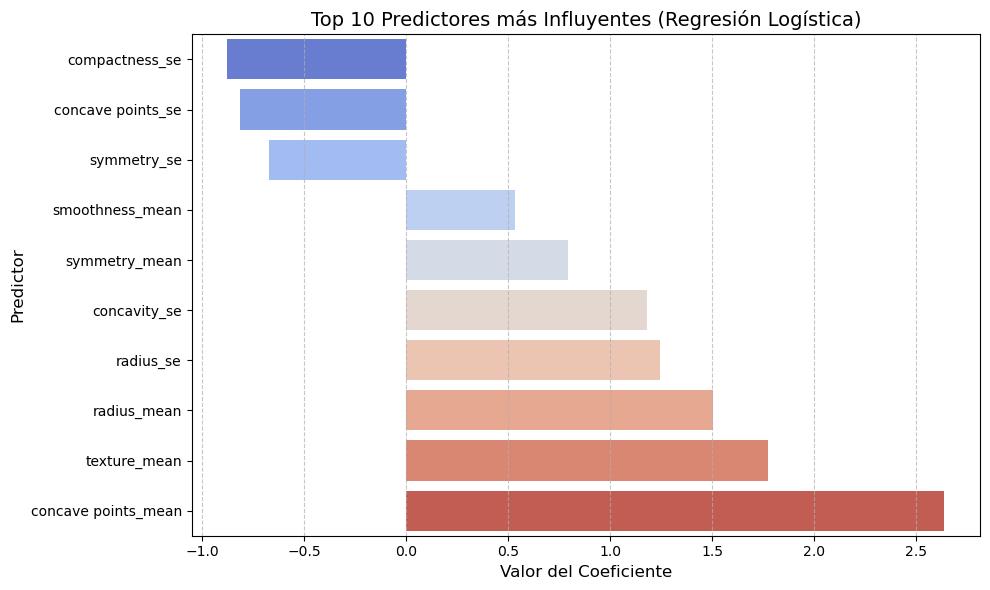

In [13]:
# ----- Obtener los nombres de los predictores empleados -----

# Los nombres de las columnas que pasan (remainder='passthrough')
feature_names_out = pipeline_yeo.named_steps['columntransformer'].get_feature_names_out(X_train.columns)
print("\n---------------- Nombres de los predictores empleados ----------------")
print(feature_names_out)
print("15 predictores empleados")
print("-" * 70)

# ----- Revisar coeficientes del modelo (10 más influyentes) -----

# Extraer los coeficientes del modelo de Regresión Logística
coefs = pipeline_yeo.named_steps['logisticregression'].coef_[0]

# Crear un DataFrame para análisis
coefs_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
})

# Identificar las 10 variables más influyentes (mayor valor absoluto)
top_10_coefs = coefs_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print("\n----- Top 10 Variables más Influyentes (Coeficientes) -----")
print(top_10_coefs[['Feature', 'Coefficient']].to_markdown(index=False, numalign="left", stralign="left"))


# ----- Graficar las variables más influyentes -----

plt.figure(figsize=(10, 6))
# Ordenar de mayor a menor coeficiente absoluto para el gráfico
top_10_coefs_sorted = top_10_coefs.sort_values(by='Coefficient', ascending=True)

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_10_coefs_sorted,
    hue='Feature',
    palette=sns.color_palette("coolwarm", len(top_10_coefs_sorted)),
    legend=False
)

plt.title('Top 10 Predictores más Influyentes (Regresión Logística)', fontsize=14)
plt.xlabel('Valor del Coeficiente', fontsize=12)
plt.ylabel('Predictor', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
plt.close()


9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

----- DataFrame de Resultados -----
| Modelo            | Recall   | Precision   | Accuracy   |
|:------------------|:---------|:------------|:-----------|
| Correlation_Clean | 0.928571 | 1           | 0.973684   |
| Standard_PCA      | 0.97619  | 0.97619     | 0.982456   |
| Correlation_Yeo   | 0.952381 | 1           | 0.982456   |

----- Modelo Seleccionado para Análisis: Standard_PCA (Mejor Recall y Accuracy) -----


<Figure size 600x500 with 0 Axes>

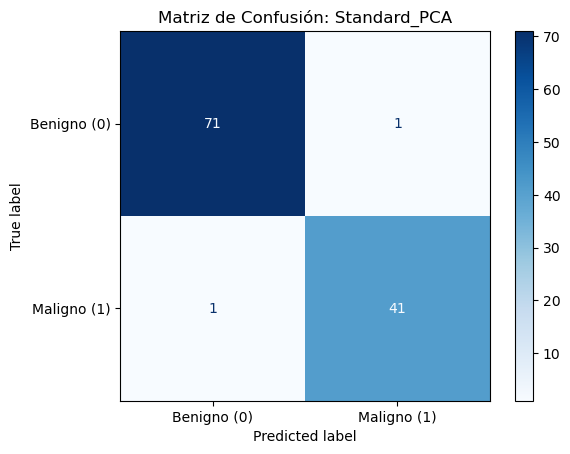

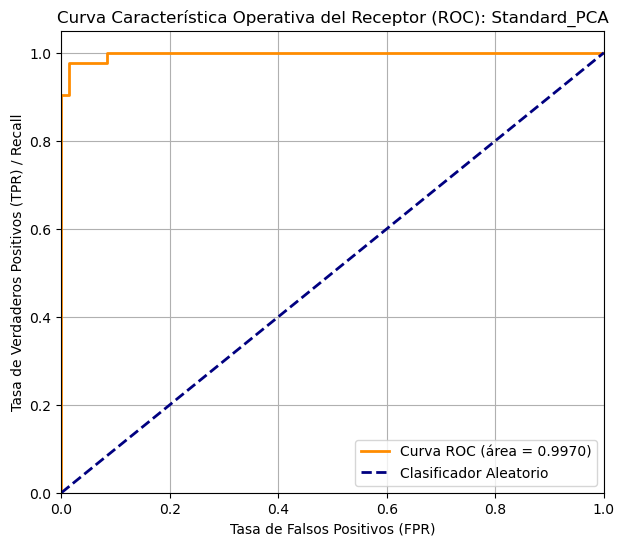

In [14]:


print("----- DataFrame de Resultados -----")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

print("\n----- Modelo Seleccionado para Análisis: Standard_PCA (Mejor Recall y Accuracy) -----")

cm = confusion_matrix(y_test, y_pred_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno (0)', 'Maligno (1)'])

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión: Standard_PCA')
plt.show()
plt.close()


# ----- Definición y Entrenamiento del MEJOR MODELO (Standard_PCA) -----
# Se utiliza el modelo Standard_PCA por su alto Recall y Accuracy.
standard_pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.9), # Mantiene el 90% de la varianza
    LogisticRegression(random_state=1)
)
standard_pca_pipeline.fit(X_train, y_train)

y_pred_pca = standard_pca_pipeline.predict(X_test)
y_prob_pca = standard_pca_pipeline.predict_proba(X_test)[:, 1]

# ----- Dibuja la curva ROC -----

fpr, tpr, thresholds = roc_curve(y_test, y_prob_pca)
roc_auc = roc_auc_score(y_test, y_prob_pca)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
plt.title('Curva Característica Operativa del Receptor (ROC): Standard_PCA')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.close()

# Describe lo que indica sobre su capacidad para distinguir entre clases.
# La curva ROC del modelo Standar_PCA muestra un área bajo la curva (AUC) de 0.9970, 
# lo que indica una excelente capacidad para distinguir entre tumores benignos y malignos. 
# La curva se mantiene muy por encima de la diagonal aleatoria, reflejando alta sensibilidad y baja tasa de falsos negativos.

10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

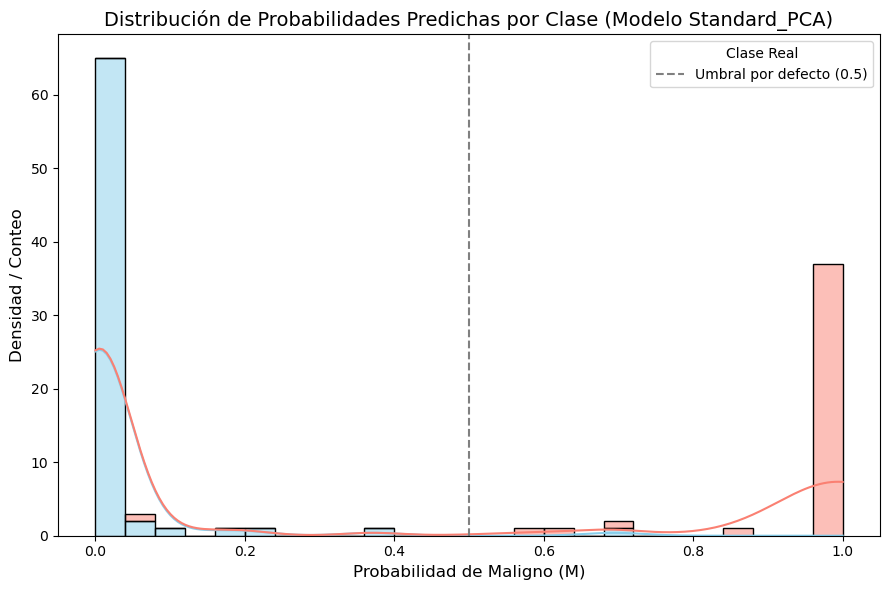

In [15]:
# Obtener las probabilidades predichas para la clase Maligna (Clase 1)
y_prob_pca = standard_pca_pipeline.predict_proba(X_test)[:, 1]

# Crear un DataFrame con las probabilidades y las etiquetas reales (mapeadas a string para el hue)
prob_df = pd.DataFrame({
    'Probabilidad Maligno (M)': y_prob_pca,
    'Clase Real': y_test.map({0: 'Benigno (B)', 1: 'Maligno (M)'})
})

# ----- Graficar la distribución de probabilidades -----
plt.figure(figsize=(9, 6))
sns.histplot(
    data=prob_df,
    x='Probabilidad Maligno (M)',
    hue='Clase Real',
    multiple='stack', # Histograma apilado
    kde=True,
    bins=25,
    palette={'Benigno (B)': 'skyblue', 'Maligno (M)': 'salmon'}
)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral por defecto (0.5)')
plt.title('Distribución de Probabilidades Predichas por Clase (Modelo Standard_PCA)', fontsize=14)
plt.xlabel('Probabilidad de Maligno (M)', fontsize=12)
plt.ylabel('Densidad / Conteo', fontsize=12)
plt.legend(title='Clase Real')
plt.tight_layout()
plt.show()
plt.close()